<a href="https://colab.research.google.com/github/martinsena6/gimnasio-analisis/blob/main/PrimerTrabajoAnalisisDatos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ANALISIS DE DATOS

## 1- ETL (Extraccion-Transformacion y Carga de Datos)

### -1.1 Extraccion

In [1]:
#Extraemos la base de Datos de un gimnasio
from google.colab import drive
import pandas as pd
import chardet

#con este comando se monta google drive para acceder al archivo que cargamos
drive.mount('/content/drive', force_remount=True)

ruta_archivo = '/content/drive/MyDrive/PrimerTrabajoAnalisisDatos/Final_data.csv'
with open(ruta_archivo, 'rb') as f:
  result = chardet.detect(f.read())


try:
  df = pd.read_csv(ruta_archivo, encoding=result['encoding'], sep=',', decimal=',')
  print('extracción de datos exitosa')
except FileNotFoundError:
  print(f'El archivo no se encuentra en la ruta especificada: {ruta_archivo}')

Mounted at /content/drive
extracción de datos exitosa


### -1.2 Transformacion

In [2]:
# Exploramos que datos nos muestran las primeras 10 filas del Data Frame para empezar a transformarlos de ser necesario
df.head(10)

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,...,cal_from_macros,pct_carbs,protein_per_kg,pct_HRR,pct_maxHR,cal_balance,lean_mass_kg,expected_burn,Burns Calories (per 30 min)_bc,Burns_Calories_Bin
0,34.91,Male,65.27,1.62,188.58,157.65,69.05,1.0,1080.9,Strength,...,2139.59,0.5004323258194326,1.624789336601808,0.7412365096628462,0.8359847279669106,725.0999999999999,47.77739381514478,685.16,7.260425438142023e+19,Medium
1,23.37,Female,56.41,1.55,179.43,131.75,73.18,1.37,1809.91,HIIT,...,1711.65,0.5008500569625799,1.5140932458783904,0.5512470588235293,0.7342696316112133,-232.91000000000008,40.8098026823542,978.6184000000002,1.02050570044361e+20,High
2,33.2,Female,58.98,1.67,175.04,123.95,54.96,0.91,802.26,Cardio,...,1965.92,0.5006104012370798,1.6634452356731095,0.5745336442371753,0.708123857404022,805.74,44.63557970100271,654.5266,1.0796070881410969e+20,High
3,38.69,Female,93.78,1.7,191.21,155.1,50.07,1.1,1450.79,HIIT,...,1627.28,0.499532962981171,0.8620174877372574,0.7441547399744933,0.811150044453742,1206.21,63.00743237900567,773.63,8.987921156899057e+19,High
4,45.09,Male,52.42,1.88,193.58,152.88,70.84,1.08,1166.4,Strength,...,2659.2300000000005,0.5005809952505048,2.538153376573827,0.6684047580250936,0.7897510073354684,303.5999999999999,43.34750358810577,711.4176000000001,5.264684819918977e+19,Low
5,53.19,Female,105.05,1.84,176.52,130.6,61.84,0.69,453.33,Yoga,...,1369.66,0.4989851495991706,0.6465492622560686,0.5995814440181373,0.7398595060049852,2313.67,71.38245822835935,516.8928,1.505159478350823e+20,Very High
6,23.17,Male,58.41,1.78,184.75,140.9,58.01,1.67,1953.9,Strength,...,2245.45,0.4993742902313567,1.923472008217771,0.6540160959444533,0.7626522327469554,-86.90000000000009,46.4089108397424,1098.6596,5.2101061937090404e+19,Low
7,55.92,Female,84.07,1.63,183.87,141.12,51.79,1.01,727.81,Yoga,...,2105.25,0.4988861180382377,1.2538360889734743,0.6763325257419746,0.767498776309349,1463.19,57.093470262707264,734.3912,1.179845981806973e+20,Very High
8,24.11,Female,88.58,1.79,176.78,154.07,65.19,1.76,2062.37,Strength,...,1383.27,0.5004952033948543,0.7839241363738992,0.7964871404247692,0.871535241543161,524.6300000000001,64.33809369821437,1230.2752,8.55076051981236e+19,High
9,39.19,Female,50.32,1.6,166.88,128.04,49.91,1.17,1157.25,Strength,...,1527.67,0.5002651096113689,1.5254372019077902,0.6679490467641275,0.7672579098753595,89.75,39.29520041276037,763.5654,4.879493878779312e+19,Low


In [3]:
# 🔹 Renombramos la columna original en ingles pasamos a columnas en español
renombrar_columnas = {
    'Age': 'Edad', 'Gender': 'Género', 'Weight (kg)': 'Peso (kg)',  'Height (m)': 'Altura (m)', 'Max_BPM': 'Frecuencia cardíaca máxima (ppm)', 'Avg_BPM': 'Frecuencia cardíaca promedio (ppm)',
    'Resting_BPM': 'Frecuencia cardíaca en reposo (ppm)',   'Session_Duration (hours)': 'Duración de la sesión (horas)',
    'Calories_Burned': 'Calorías quemadas', 'Workout_Type': 'Tipo de entrenamiento',   'Fat_Percentage': 'Porcentaje de grasa',  'Water_Intake (liters)': 'Ingesta de agua (litros)',
    'Workout_Frequency (days/week)': 'Frecuencia de entrenamiento (días/semana)', 'Experience_Level': 'Nivel de experiencia',  'BMI': 'Índice de masa corporal (IMC)',  'Daily meals frequency': 'Frecuencia de comidas diarias',
    'Physical exercise': 'Ejercicio físico', 'Carbs': 'Carbohidratos',  'Proteins': 'Proteínas', 'Fats': 'Grasas',   'Calories': 'Calorías',  'meal_name': 'Nombre de la comida', 'meal_type': 'Tipo de comida',  'diet_type': 'Tipo de dieta',
    'sugar_g': 'Azúcar (g)', 'sodium_mg': 'Sodio (mg)',  'cholesterol_mg': 'Colesterol (mg)', 'serving_size_g': 'Tamaño de porción (g)','cooking_method': 'Método de cocción',
    'prep_time_min': 'Tiempo de preparación (min)',  'cook_time_min': 'Tiempo de cocción (min)', 'rating': 'Valoración',  'is_healthy': 'Es saludable',  'Name of Exercise': 'Nombre del ejercicio', 'Sets': 'Series',  'Reps': 'Repeticiones',  'Benefit': 'Beneficio',
    'Burns Calories (per 30 min)': 'Calorías quemadas (por 30 min)', 'Target Muscle Group': 'Grupo muscular objetivo', 'Equipment Needed': 'Equipo necesario',
    'Difficulty Level': 'Nivel de dificultad', 'Body Part': 'Parte del cuerpo', 'Type of Muscle': 'Tipo de músculo', 'Workout': 'Entrenamiento', 'BMI_CALc': 'Cálculo de IMC',  'cal_from_macros': 'Calorías de macronutrientes',
    'pct_carbs': 'Porcentaje de carbohidratos', 'protein_per_kg': 'Proteína por kilogramo',   'pct_HRR': 'Porcentaje de frecuencia cardíaca de reserva',  'pct_MAXHR': 'Porcentaje de frecuencia cardíaca máxima',
    'cal_balance': 'Balance calórico',  'lea_mass_kg': 'Masa magra (kg)',  'BMI_CALc': 'Cálculo de IMC',  'cal_from_macros': 'Calorías de macronutrientes',
    'pct_carbs': 'Porcentaje de carbohidratos',  'protein_per_kg': 'Proteína por kilogramo',    'pct_HRR': 'Porcentaje de frecuencia cardíaca de reserva',
    'pct_MAXHR': 'Porcentaje de frecuencia cardíaca máxima',  'cal_balance': 'Balance calórico',  'lea_mass_kg': 'Masa magra (kg)',   'pct_maxHR': 'Porcentaje de frecuencia cardíaca máxima', 'lean_mass_kg': 'Masa magra (kg)',  'expected_burn': 'Calorías esperadas a quemar', 'Burns Calories (per 30 min)_bc': 'Calorías quemadas (por 30 min)',  'Burns_Calories_Bin': 'Calorías quemadas (binario)'
}

# 🔹 Renombrar columnas en el DataFrame
df = df.rename(columns=renombrar_columnas)
print("Transformación de Datos exitosa!")

Transformación de Datos exitosa!


In [4]:
# Eliminamos columnas que no hacen a la investigacion que queremos realizar
df.drop(
    columns=[
'Frecuencia cardíaca máxima (ppm)',
        'Frecuencia cardíaca promedio (ppm)',
        'Frecuencia cardíaca en reposo (ppm)',
        'Ejercicio físico',
        'Carbohidratos',
        'Proteínas',
        'Grasas',
        'Calorías',
        'Nombre de la comida',
        'Tipo de comida',
        'Tipo de dieta',
        'Azúcar (g)',
        'Sodio (mg)',
        'Colesterol (mg)',
        'Tamaño de porción (g)',
        'Método de cocción',
        'Tiempo de preparación (min)',
        'Tiempo de cocción (min)',
        'Valoración',
        'Es saludable',
        'Nombre del ejercicio',
        'Series',
        'Repeticiones',
        'Beneficio',
        'Calorías quemadas (por 30 min)',
        'Grupo muscular objetivo',
        'Equipo necesario',
        'Parte del cuerpo',
        'Tipo de músculo',
        'Cálculo de IMC',
        'Calorías de macronutrientes',
        'Porcentaje de carbohidratos',
        'Proteína por kilogramo',
        'Porcentaje de frecuencia cardíaca de reserva',
        'Porcentaje de frecuencia cardíaca máxima',
        'Balance calórico',
        'Masa magra (kg)',
        'Calorías esperadas a quemar',
        'Calorías quemadas (por 30 min)',
        'Calorías quemadas (binario)'
        'Calorías esperadas a quemar',
          'Ingesta de agua (litros)',
    'Frecuencia de comidas diarias',
    'Entrenamiento',
    'BMI_calc',
    'Calorías quemadas (binario)',
	'Índice de masa corporal (IMC)',
 'Porcentaje de grasa',
'Calorías quemadas',
"Nivel de experiencia"
    ],
    inplace=True,  # <- esto modifica el DataFrame original
    errors='ignore'  # <- evita error si alguna columna no existe
)


In [18]:
# Creo un Diccionario con los precios por tipo de entrenamiento para analizar ingresos por actividad
precios = {
    "Fuerza": 18000,    # Entrenamiento de fuerza
    "Entrenamiento intenso": 16000,        # Alta intensidad
    "Cardio": 14000,      # Cardio
    "Yoga": 12000         # Yoga
}

# Crear una nueva columna con el precio de cada tipo de entrenamiento
df["Precio_Cuota"] = df["Tipo de entrenamiento"].map(precios)

# Verificamos que se haya agregado correctamente
df.head()

,Edad,Género,Peso (kg),Altura (m),Duración de la sesión (horas),Tipo de entrenamiento,Frecuencia de entrenamiento (días/semana),Nivel de dificultad,Precio_Cuota,Rango_Edad
0,34,M,65.27,1.62,01:00:00,Fuerza,3,Avanzado,18000,31-40
1,23,F,56.41,1.55,01:22:12,Entrenamiento intenso,4,Intermedio,16000,18-30
2,33,F,58.98,1.67,00:54:36,Cardio,2,Intermedio,14000,31-40
3,38,F,93.78,1.70,01:06:00,Entrenamiento intenso,3,Avanzado,16000,31-40
4,45,M,52.42,1.88,01:04:48,Fuerza,4,Avanzado,18000,41-49


In [15]:
# Nos da un Resumen de la Informacion del Data Frame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 10 columns):
 #   Column                                     Non-Null Count  Dtype   
---  ------                                     --------------  -----   
 0   Edad                                       20000 non-null  int64   
 1   Género                                     20000 non-null  object  
 2   Peso (kg)                                  20000 non-null  float64 
 3   Altura (m)                                 20000 non-null  float64 
 4   Duración de la sesión (horas)              20000 non-null  object  
 5   Tipo de entrenamiento                      20000 non-null  object  
 6   Frecuencia de entrenamiento (días/semana)  20000 non-null  int64   
 7   Nivel de dificultad                        20000 non-null  object  
 8   Precio_Cuota                               9955 non-null   float64 
 9   Rango_Edad                                 20000 non-null  category
dtypes: categor

In [16]:
# Exploramos el tipo de cada dato para ver cuales necesitan transformacion
df.dtypes

,0
Edad,int64
Género,object
Peso (kg),float64
Altura (m),float64
Duración de la sesión (horas),object
Tipo de entrenamiento,object
Frecuencia de entrenamiento (días/semana),int64
Nivel de dificultad,object
Precio_Cuota,float64
Rango_Edad,category


In [8]:
#Transformamos la calidad de los datos
# 🔸 1️⃣ Transformar Edad → entero
if 'Edad' in df.columns:
    df['Edad'] = pd.to_numeric(df['Edad'], errors='coerce').fillna(0).astype(int)

# 🔸 2️⃣ Transformar Frecuencia de entrenamiento → entero
col_freq = 'Frecuencia de entrenamiento (días/semana)'
if col_freq in df.columns:
    df[col_freq] = pd.to_numeric(df[col_freq], errors='coerce').fillna(0).astype(int)

# 🔸 3️⃣ Transformar Peso y Altura → float
for col in ['Peso (kg)', 'Altura (m)']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').astype(float)

# 🔸 4️⃣ Transformar Duración de la sesión (horas) → formato HH:MM:SS
col_duracion = 'Duración de la sesión (horas)'
if col_duracion in df.columns:
    # Convertir valores a número
    df[col_duracion] = pd.to_numeric(df[col_duracion], errors='coerce')

    # Convertir de horas (ej. 1.5) a timedelta
    duracion_td = pd.to_timedelta(df[col_duracion], unit='h')

    # Formatear como texto "HH:MM:SS"
    df[col_duracion] = duracion_td.dt.components.apply(
        lambda x: f"{int(x['hours']):02d}:{int(x['minutes']):02d}:{int(x['seconds']):02d}", axis=1
    )

# 🔸 5️⃣ Mostrar los primeros valores para verificar
print("✅ Transformaciones completadas correctamente:\n")
print(df[['Edad', col_freq, 'Peso (kg)', 'Altura (m)', col_duracion]].head())

✅ Transformaciones completadas correctamente:

   Edad  Frecuencia de entrenamiento (días/semana)  Peso (kg)  Altura (m)  \
0    34                                          3      65.27        1.62   
1    23                                          4      56.41        1.55   
2    33                                          2      58.98        1.67   
3    38                                          3      93.78        1.70   
4    45                                          4      52.42        1.88   

  Duración de la sesión (horas)  
0                      01:00:00  
1                      01:22:12  
2                      00:54:36  
3                      01:06:00  
4                      01:04:48  


In [17]:
# Genera estadisticas descriptivas de las columnas numericas del Data Frame
df.describe()

,Edad,Peso (kg),Altura (m),Frecuencia de entrenamiento (días/semana),Precio_Cuota
count,20000.000000,20000.000000,20000.000000,20000.000000,9955.000000
mean,38.369550,73.898832,1.723093,2.922700,12989.050728
std,12.105693,21.173010,0.127033,1.033382,999.990282
min,18.000000,39.180000,1.490000,1.000000,12000.000000
25%,28.000000,58.160000,1.620000,2.000000,12000.000000
50%,39.000000,70.000000,1.710000,3.000000,12000.000000
75%,49.000000,86.100000,1.800000,4.000000,14000.000000
max,59.000000,130.770000,2.010000,5.000000,14000.000000


In [10]:
#reemplazamos las columnas dentro de Género de Female y Male a F y M
df['Género'] = df['Género'].str.replace('Female', 'F')
df['Género'] = df['Género'].str.replace('Male', 'M')

In [11]:
#Miramos que hay dentro de las listas
print(list(df["Tipo de entrenamiento"].unique()))
print(list(df["Género"].unique()))
print(list(df["Nivel de dificultad"].unique()))


['Strength', 'HIIT', 'Cardio', 'Yoga']
['M', 'F']
['Advanced', 'Intermediate', 'Beginner']


In [13]:
#Pasamos a español
df["Tipo de entrenamiento"] = df["Tipo de entrenamiento"].replace({
    "Strength": "Fuerza",
    "HIIT": "Entrenamiento intenso",
    "Cardio": "Cardio",
    "Yoga": "Yoga"
})
df["Nivel de dificultad"] = df["Nivel de dificultad"].replace({
    "Advanced": "Avanzado",
    "Intermediate": "Intermedio",
    "Beginner": "Principiante"
})

In [14]:
# 1) Asegurarnos de que Edad sea numérica (si hay strings, se convierten a NaN)
df['Edad'] = pd.to_numeric(df['Edad'], errors='coerce')

# 2) Crear la columna Rango_Edad (solo adultos desde 18 en adelante)
bins = [17, 30, 40, 49, 200]                        # cortes: (17,30], (30,40], (40,49], (49,200]
labels = ['18-30', '31-40', '41-49', '50+']
df['Rango_Edad'] = pd.cut(df['Edad'], bins=bins, labels=labels, right=True)

# (Opcional) Si querés que la columna sea categórica ordenada (útil para ordenar resultados)
df['Rango_Edad'] = pd.Categorical(df['Rango_Edad'], categories=labels, ordered=True)


In [ ]:
#Volvemos a verificar nuestra informacion antes de la carga a los pasos de
# info - describe- types

### -1.3 Carga

In [19]:
#Hacemos la carga de datos
ruta_salida = '/content/drive/MyDrive/PrimerTrabajoAnalisisDatos/Final_dataTransformadas.csv'

df.to_csv(ruta_salida, index=False, sep= ',')
print(f'extracción de datos exitosa en: {ruta_salida}')

extracción de datos exitosa en: /content/drive/MyDrive/PrimerTrabajoAnalisisDatos/Final_dataTransformadas.csv


## 2- EDA (Analisis Exploratorio de Datos)

In [21]:
# Una vez que terminamos de hacer la transformacion comenzamos con el analisis especifico de los datos
# Queremos saber actividades que mas realizan, grupo de rangos de edad
# Separar entre hombres y mujeres
# saber los ingresos de cada actividad para empezar a ver las posibles decisiones a tomar

In [22]:
# Dividir los grupos por Genero para saber la cantidad de mujeres y hombres que van al gimnasio
print(df.groupby(['Género'])['Edad'].count())

Género
F    10028
M     9972
Name: Edad, dtype: int64


In [23]:
resumen_entrenamiento = (
    df.groupby('Tipo de entrenamiento')
      .agg(
          Cantidad=('Edad', 'count'),
          Total_Monto_Cuotas=('Precio_Cuota', 'sum')
      )
      .sort_values(by='Total_Monto_Cuotas', ascending=False)
)


# ➕ Agregar la fila total general al final
resumen_entrenamiento.loc["TOTAL GENERAL"] = [
    resumen_entrenamiento['Cantidad'].sum(),
    resumen_entrenamiento['Total_Monto_Cuotas'].sum()
]

# Mostrar el resultado
print(resumen_entrenamiento)

                       Cantidad  Total_Monto_Cuotas
Tipo de entrenamiento                              
Fuerza                     5071            91278000
Entrenamiento intenso      4974            79584000
Cardio                     4923            68922000
Yoga                       5032            60384000
TOTAL GENERAL             20000           300168000


In [24]:
# Agrupar por Género y Tipo de entrenamiento
resumen = (
    df.groupby(['Género', 'Tipo de entrenamiento'])
    .agg(
        Cantidad=('Edad', 'count'),          # cantidad de personas
        Total_Cuotas=('Precio_Cuota', 'sum') # suma total de las cuotas
    )
    .sort_values(by='Total_Cuotas', ascending=False)
)

# ➕ Agregar una fila con el total general
resumen.loc[("TOTAL GENERAL", ""), :] = [
    resumen['Cantidad'].sum(),
    resumen['Total_Cuotas'].sum()
]

# Mostrar el resumen con totales
print(resumen)

                                     Cantidad  Total_Cuotas
Género        Tipo de entrenamiento                        
F             Fuerza                   2601.0    46818000.0
M             Fuerza                   2470.0    44460000.0
              Entrenamiento intenso    2495.0    39920000.0
F             Entrenamiento intenso    2479.0    39664000.0
M             Cardio                   2505.0    35070000.0
F             Cardio                   2418.0    33852000.0
              Yoga                     2530.0    30360000.0
M             Yoga                     2502.0    30024000.0
TOTAL GENERAL                         20000.0   300168000.0


In [25]:
# Filtrar mujeres por rango de edad
mujeres_18_30 = df[
    (df['Género'].str.lower().isin(['f', 'female', 'mujer'])) &
    (df['Edad'] >= 18) & (df['Edad'] <= 30)
]
mujeres_31_40 = df[
    (df['Género'].str.lower().isin(['f', 'female', 'mujer'])) &
    (df['Edad'] >= 31) & (df['Edad'] <= 40)
]
mujeres_41_49 = df[
    (df['Género'].str.lower().isin(['f', 'female', 'mujer'])) &
    (df['Edad'] >= 41) & (df['Edad'] <= 49)
]
mujeres_50 = df[
    (df['Género'].str.lower().isin(['f', 'female', 'mujer'])) &
    (df['Edad'] >= 50)
]

# Mostrar cantidad de mujeres
cantidad = len(mujeres_18_30)
cantidad1 = len(mujeres_31_40)
cantidad2 = len(mujeres_41_49)
cantidad3 = len(mujeres_50)

# 🔹 Calcular montos totales por grupo
monto_18_30 = mujeres_18_30["Precio_Cuota"].sum()
monto_31_40 = mujeres_31_40["Precio_Cuota"].sum()
monto_41_49 = mujeres_41_49["Precio_Cuota"].sum()
monto_50 = mujeres_50["Precio_Cuota"].sum()

# 🔹 Mostrar resultados
print(f"👩‍🦰 Hay {cantidad} mujeres entre 18 y 30 años que entrenan. Monto total cuotas: ${monto_18_30:,.0f}")
print(f"👩‍🦰 Hay {cantidad1} mujeres entre 31 y 40 años que entrenan. Monto total cuotas: ${monto_31_40:,.0f}")
print(f"👩‍🦰 Hay {cantidad2} mujeres entre 41 y 49 años que entrenan. Monto total cuotas: ${monto_41_49:,.0f}")
print(f"👩‍🦰 Hay {cantidad3} mujeres mayores de 50 años. Monto total cuotas: ${monto_50:,.0f}")

# Totales generales
total_mujeres = cantidad + cantidad1 + cantidad2 + cantidad3
total_cuotas = monto_18_30 + monto_31_40 + monto_41_49 + monto_50

print(f"\n📊 En total hay {total_mujeres} mujeres que entrenan.")
print(f"💰 Monto total general de cuotas: ${total_cuotas:,.0f}")

👩‍🦰 Hay 3136 mujeres entre 18 y 30 años que entrenan. Monto total cuotas: $47,136,000
👩‍🦰 Hay 2213 mujeres entre 31 y 40 años que entrenan. Monto total cuotas: $33,338,000
👩‍🦰 Hay 2329 mujeres entre 41 y 49 años que entrenan. Monto total cuotas: $35,004,000
👩‍🦰 Hay 2350 mujeres mayores de 50 años. Monto total cuotas: $35,216,000

📊 En total hay 10028 mujeres que entrenan.
💰 Monto total general de cuotas: $150,694,000


In [26]:
# Filtrar hombres por rango de edad
hombres_18_30 = df[
    (df['Género'].str.lower().isin(['m', 'male', 'hombre'])) &
    (df['Edad'] >= 18) & (df['Edad'] <= 30)
]
hombres_31_40 = df[
    (df['Género'].str.lower().isin(['m', 'male', 'hombre'])) &
    (df['Edad'] >= 31) & (df['Edad'] <= 40)
]
hombres_41_49 = df[
    (df['Género'].str.lower().isin(['m', 'male', 'hombre'])) &
    (df['Edad'] >= 41) & (df['Edad'] <= 49)
]
hombres_50 = df[
    (df['Género'].str.lower().isin(['m', 'male', 'hombre'])) &
    (df['Edad'] >= 50)
]

# Mostrar cantidad y monto total por grupo
cantidad = len(hombres_18_30)
monto_18_30 = hombres_18_30["Precio_Cuota"].sum()

cantidad1 = len(hombres_31_40)
monto_31_40 = hombres_31_40["Precio_Cuota"].sum()

cantidad2 = len(hombres_41_49)
monto_41_49 = hombres_41_49["Precio_Cuota"].sum()

cantidad3 = len(hombres_50)
monto_50 = hombres_50["Precio_Cuota"].sum()

# Mostrar resultados
print(f"👨 Hay {cantidad} hombres entre 18 y 30 años que entrenan. Total cuotas: ${monto_18_30:,.2f}")
print(f"👨 Hay {cantidad1} hombres entre 31 y 40 años que entrenan. Total cuotas: ${monto_31_40:,.2f}")
print(f"👨 Hay {cantidad2} hombres entre 41 y 49 años que entrenan. Total cuotas: ${monto_41_49:,.2f}")
print(f"👨 Hay {cantidad3} hombres mayores de 49 años que entrenan. Total cuotas: ${monto_50:,.2f}")

# Calcular total general
total_hombres = cantidad + cantidad1 + cantidad2 + cantidad3
total_monto_hombres = monto_18_30 + monto_31_40 + monto_41_49 + monto_50

print(f"\n📊 En total hay {total_hombres} hombres que entrenan.")
print(f"💰 Monto total de cuotas de hombres: ${total_monto_hombres:,.2f}")



👨 Hay 3051 hombres entre 18 y 30 años que entrenan. Total cuotas: $45,594,000.00
👨 Hay 2217 hombres entre 31 y 40 años que entrenan. Total cuotas: $33,380,000.00
👨 Hay 2330 hombres entre 41 y 49 años que entrenan. Total cuotas: $34,848,000.00
👨 Hay 2374 hombres mayores de 49 años que entrenan. Total cuotas: $35,652,000.00

📊 En total hay 9972 hombres que entrenan.
💰 Monto total de cuotas de hombres: $149,474,000.00


In [27]:
# Confirmamos datos para corroborar que vamos bien
print(f"💰 Monto total de cuotas entre hombres y mujeres es: ${total_monto_hombres + total_cuotas:,.2f}")

💰 Monto total de cuotas entre hombres y mujeres es: $300,168,000.00


In [29]:
# Filtramos actividades por niveles de dificultad
# con el objetivo de profundizar el analisis para futuras decisiones
# comenzamos con Cardio y creamos la tabla dinámica
df_cardio = df[df["Tipo de entrenamiento"] == "Cardio"]

tabla_pivot_cardio = (
    df_cardio.pivot_table(
        index=["Género", "Rango_Edad"],
        columns="Nivel de dificultad",
        values="Edad",
        aggfunc="count",
        fill_value=0
    )
)

print("\n📊 Tabla dinámica (solo 'Cardio') — cantidad de personas por género, edad y nivel de dificultad:\n")
print(tabla_pivot_cardio)


📊 Tabla dinámica (solo 'Cardio') — cantidad de personas por género, edad y nivel de dificultad:

Nivel de dificultad  Avanzado  Intermedio  Principiante
Género Rango_Edad                                      
F      18-30              242         241           255
       31-40              186         191           183
       41-49              179         179           192
       50+                193         187           190
M      18-30              271         267           258
       31-40              177         203           189
       41-49              193         193           179
       50+                180         202           193


/tmp/ipython-input-4048265672.py:7: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df_cardio.pivot_table(


In [30]:
# "Entrenamiento intenso"
df_entrenamiento_intenso = df[df["Tipo de entrenamiento"] == "Entrenamiento intenso"]

# Creamos la tabla dinámica igual que antes, pero con los datos filtrados
tabla_pivot_entrenamiento_intenso = (
    df_entrenamiento_intenso.pivot_table(
        index=["Género", "Rango_Edad"],               # Filas
        columns="Nivel de dificultad",                # Ya no necesitamos el tipo, es solo Entrenamiento Intenso
        values="Edad",                                # Columna numérica (para contar)
        aggfunc="count",
        fill_value=0
    )
)

print("\n📊 Tabla dinámica (solo 'Entrenamiento intenso') — cantidad de personas por género, edad y nivel de dificultad:\n")
print(tabla_pivot_entrenamiento_intenso)


📊 Tabla dinámica (solo 'Entrenamiento intenso') — cantidad de personas por género, edad y nivel de dificultad:

Nivel de dificultad  Avanzado  Intermedio  Principiante
Género Rango_Edad                                      
F      18-30              263         282           235
       31-40              168         162           178
       41-49              208         186           210
       50+                199         198           190
M      18-30              270         247           270
       31-40              164         170           174
       41-49              214         195           192
       50+                207         189           203


/tmp/ipython-input-1402266696.py:6: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df_entrenamiento_intenso.pivot_table(


In [31]:
# Filtramos solo los entrenamientos de tipo "Fuerza"
df_fuerza = df[df["Tipo de entrenamiento"] == "Fuerza"]

# Creamos la tabla dinámica igual que antes, pero con los datos filtrados
tabla_pivot_fuerza = (
    df_fuerza.pivot_table(
        index=["Género", "Rango_Edad"],               # Filas
        columns="Nivel de dificultad",                # Ya no necesitamos el tipo, es solo Fuerza
        values="Edad",                                # Columna numérica (para contar)
        aggfunc="count",
        fill_value=0
    )
)

print("\n📊 Tabla dinámica (solo 'Fuerza') — cantidad de personas por género, edad y nivel de dificultad:\n")
print(tabla_pivot_fuerza)


📊 Tabla dinámica (solo 'Fuerza') — cantidad de personas por género, edad y nivel de dificultad:

Nivel de dificultad  Avanzado  Intermedio  Principiante
Género Rango_Edad                                      
F      18-30              278         269           271
       31-40              216         190           199
       41-49              222         200           168
       50+                197         196           195
M      18-30              228         225           254
       31-40              198         184           219
       41-49              187         186           186
       50+                180         242           181


/tmp/ipython-input-3425644342.py:6: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df_fuerza.pivot_table(


In [32]:
# Filtramos solo los entrenamientos de tipo "Yoga"
df_yoga = df[df["Tipo de entrenamiento"] == "Yoga"]

# Creamos la tabla dinámica igual que antes, pero con los datos filtrados
tabla_pivot_yoga = (
    df_yoga.pivot_table(
        index=["Género", "Rango_Edad"],               # Filas
        columns="Nivel de dificultad",                # Ya no necesitamos el tipo, es solo Yoga
        values="Edad",                                # Columna numérica (para contar)
        aggfunc="count",
        fill_value=0
    )
)

print("\n📊 Tabla dinámica (solo 'Yoga') — cantidad de personas por género, edad y nivel de dificultad:\n")
print(tabla_pivot_yoga)


📊 Tabla dinámica (solo 'Yoga') — cantidad de personas por género, edad y nivel de dificultad:

Nivel de dificultad  Avanzado  Intermedio  Principiante
Género Rango_Edad                                      
F      18-30              267         288           245
       31-40              167         175           198
       41-49              176         225           184
       50+                186         201           218
M      18-30              246         267           248
       31-40              189         168           182
       41-49              208         184           213
       50+                198         204           195


/tmp/ipython-input-830513641.py:6: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df_yoga.pivot_table(


/tmp/ipython-input-2572125303.py:111: UserWarning: Glyph 128203 (\N{CLIPBOARD}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.95])
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128203 (\N{CLIPBOARD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


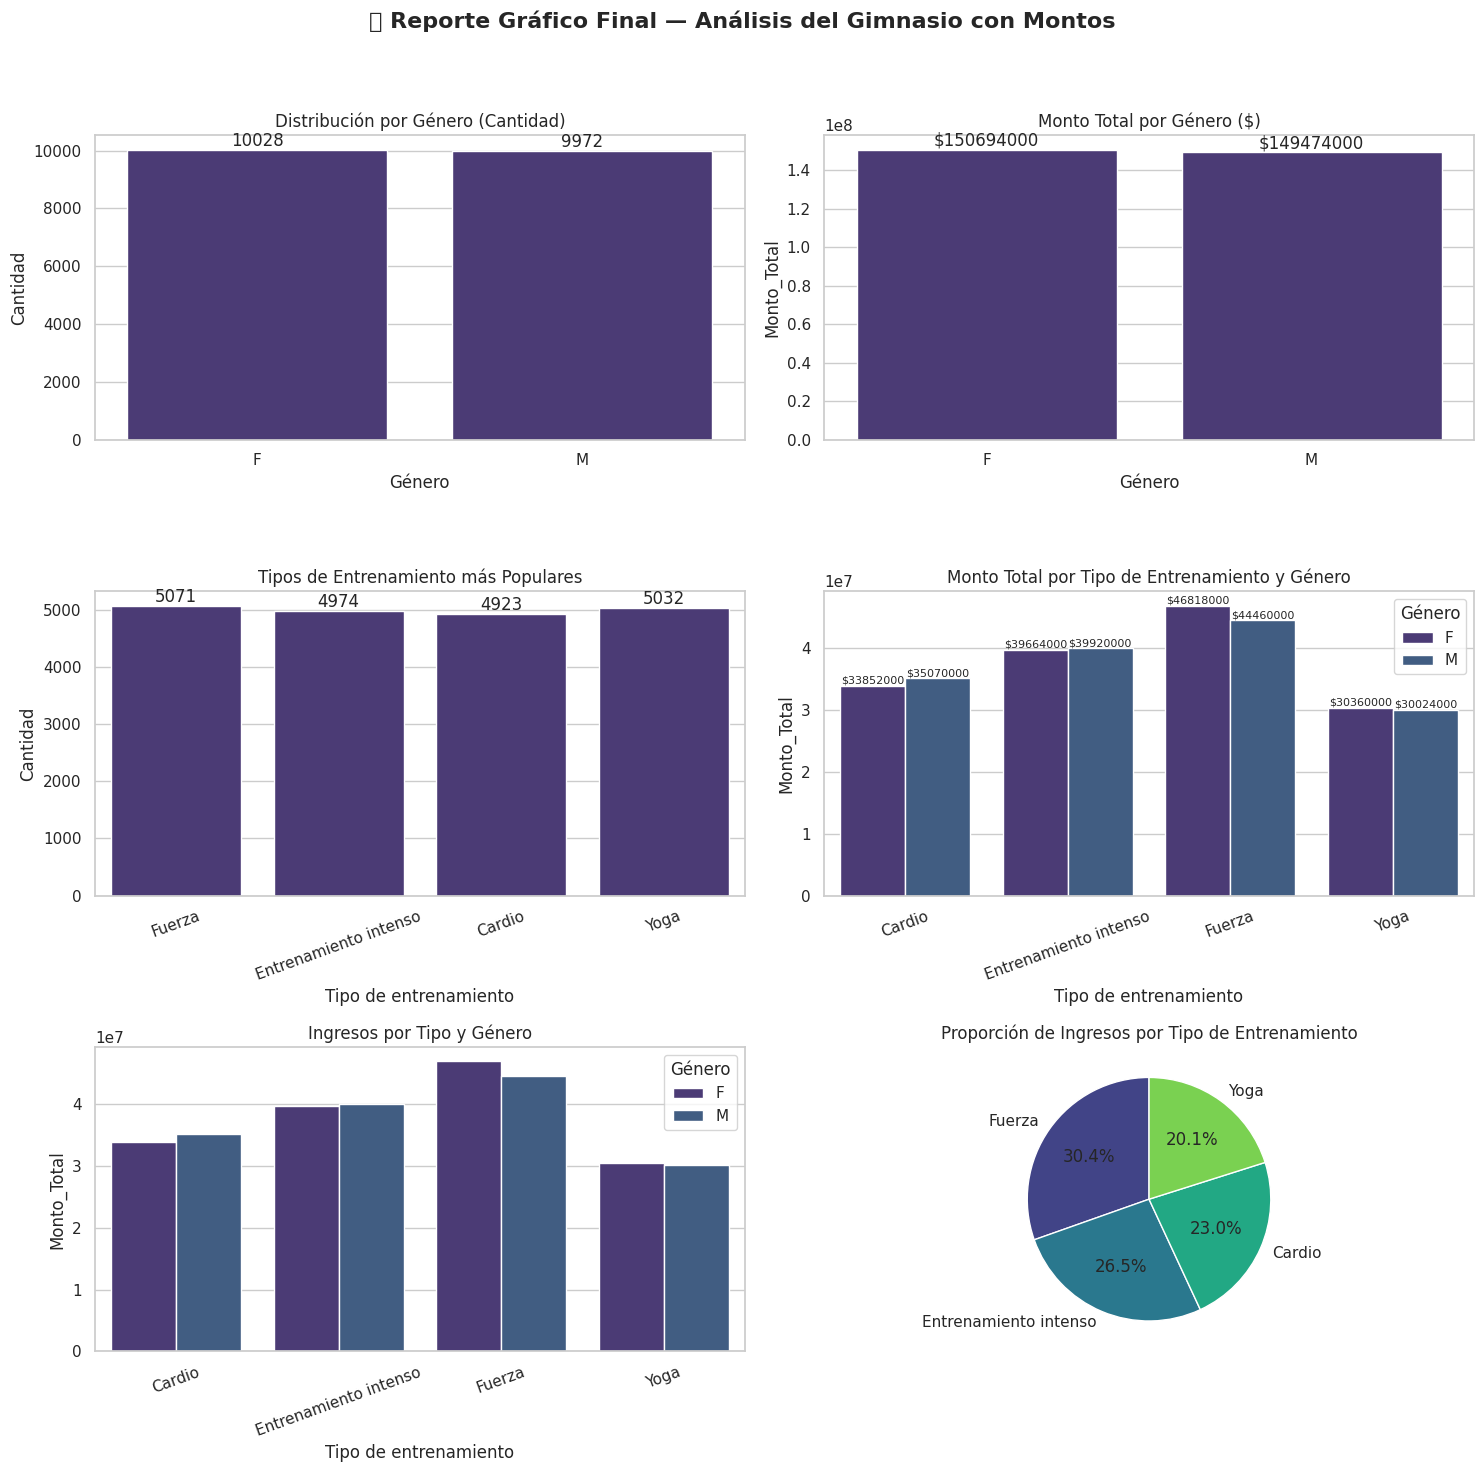

👥 Total de personas que entrenan: 20,000
💰 Ingresos totales estimados: $300,168,000.00

📊 Totales por tipo de entrenamiento:
   Tipo de entrenamiento  Cantidad  Monto_Total
2                 Fuerza      5071     91278000
1  Entrenamiento intenso      4974     79584000
0                 Cardio      4923     68922000
3                   Yoga      5032     60384000


In [33]:
# 📊 PANEL FINAL — ANÁLISIS COMPLETO DEL GIMNASIO (versión automática)
# Con ayuda de la Ia realizo una imagen ilustrativa para poder mostrar los resultados con graficas


import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ---------------- DATOS AUTOMÁTICOS ---------------- #

# Totales por género
totales = (
    df.groupby("Género")
      .agg(
          Cantidad=("Edad", "count"),
          Monto_Total=("Precio_Cuota", "sum")
      )
      .reset_index()
)

# Totales por tipo de entrenamiento
tipos_entrenamiento = (
    df.groupby("Tipo de entrenamiento")
      .agg(
          Cantidad=("Edad", "count"),
          Monto_Total=("Precio_Cuota", "sum")
      )
      .reset_index()
      .sort_values("Monto_Total", ascending=False)
)

# Totales por género y tipo
genero_tipo = (
    df.groupby(["Género", "Tipo de entrenamiento"])
      .agg(
          Cantidad=("Edad", "count"),
          Monto_Total=("Precio_Cuota", "sum")
      )
      .reset_index()
)

# Distribución por rango etario
def clasificar_edad(edad):
    if 18 <= edad <= 30:
        return "18-30"
    elif 31 <= edad <= 40:
        return "31-40"
    elif 41 <= edad <= 49:
        return "41-49"
    else:
        return "50+"

df["Rango_Edad"] = df["Edad"].apply(clasificar_edad)

rango_edad = (
    df.groupby("Rango_Edad")
      .agg(Cantidad=("Edad", "count"))
      .reset_index()
      .sort_values("Rango_Edad")
)

# ---------------- VISUALIZACIÓN ---------------- #
sns.set(style="whitegrid", palette="viridis")
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
fig.suptitle("📋 Reporte Gráfico Final — Análisis del Gimnasio con Montos", fontsize=16, fontweight="bold")

# --- 1️⃣ Distribución por género ---
sns.barplot(data=totales, x="Género", y="Cantidad", ax=axes[0, 0])
axes[0, 0].set_title("Distribución por Género (Cantidad)")
axes[0, 0].bar_label(axes[0, 0].containers[0])

# --- 2️⃣ Monto total por género ---
sns.barplot(data=totales, x="Género", y="Monto_Total", ax=axes[0, 1])
axes[0, 1].set_title("Monto Total por Género ($)")
axes[0, 1].bar_label(axes[0, 1].containers[0], fmt='$%.0f')

# --- 3️⃣ Tipos de entrenamiento ---
sns.barplot(data=tipos_entrenamiento, x="Tipo de entrenamiento", y="Cantidad", ax=axes[1, 0])
axes[1, 0].set_title("Tipos de Entrenamiento más Populares")
axes[1, 0].tick_params(axis='x', rotation=20)
axes[1, 0].bar_label(axes[1, 0].containers[0])

# --- 4️⃣ Monto total por tipo y género ---
sns.barplot(
    data=genero_tipo,                     # usamos la tabla que ya agrupa por género y tipo
    x="Tipo de entrenamiento",
    y="Monto_Total",
    hue="Género",
    ax=axes[1, 1]
)
axes[1, 1].set_title("Monto Total por Tipo de Entrenamiento y Género")
axes[1, 1].tick_params(axis='x', rotation=20)
axes[1, 1].legend(title="Género", loc="upper right")
for container in axes[1, 1].containers:
    axes[1, 1].bar_label(container, fmt='$%.0f', label_type='edge', fontsize=8)

# --- 5️⃣ Ingresos por tipo y género ---
sns.barplot(data=genero_tipo, x="Tipo de entrenamiento", y="Monto_Total", hue="Género", ax=axes[2, 0])
axes[2, 0].set_title("Ingresos por Tipo y Género")
axes[2, 0].tick_params(axis='x', rotation=20)

# --- 6️⃣ Proporción total de ingresos (torta) ---
axes[2, 1].pie(
    tipos_entrenamiento["Monto_Total"],
    labels=tipos_entrenamiento["Tipo de entrenamiento"],
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette("viridis", len(tipos_entrenamiento))
)
axes[2, 1].set_title("Proporción de Ingresos por Tipo de Entrenamiento")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# ---------------- RESUMEN FINAL ---------------- #
total_personas = len(df)
total_ingresos = df["Precio_Cuota"].sum()

print(f"👥 Total de personas que entrenan: {total_personas:,}")
print(f"💰 Ingresos totales estimados: ${total_ingresos:,.2f}")
print("\n📊 Totales por tipo de entrenamiento:")
print(tipos_entrenamiento)

